# SkillCraft Technology  
## Data Science Task 4: Traffic Accident Analysis


# Accident Analysis by Time of Day

- Imported necessary libraries: pandas, seaborn, matplotlib.
- Loaded a sample of 200,000 rows from `US_Accidents_March23.csv` using selected columns (`Start_Time`, `Start_Lat`, `Start_Lng`, `Weather_Condition`, `Severity`).
- Cleaned the `Start_Time` column by removing unwanted parts and converted it to datetime format.
- Extracted the hour from `Start_Time` into a new `Hour` column.
- Verified the processed data by displaying the first few rows.
- Plotted the number of accidents against each hour of the day using a seaborn countplot.
- Customized the plot with title, axis labels, and better layout for visualization.


           Start_Time  Hour
0 2016-02-08 05:46:00     5
1 2016-02-08 06:07:59     6
2 2016-02-08 06:49:27     6
3 2016-02-08 07:23:34     7
4 2016-02-08 07:39:07     7


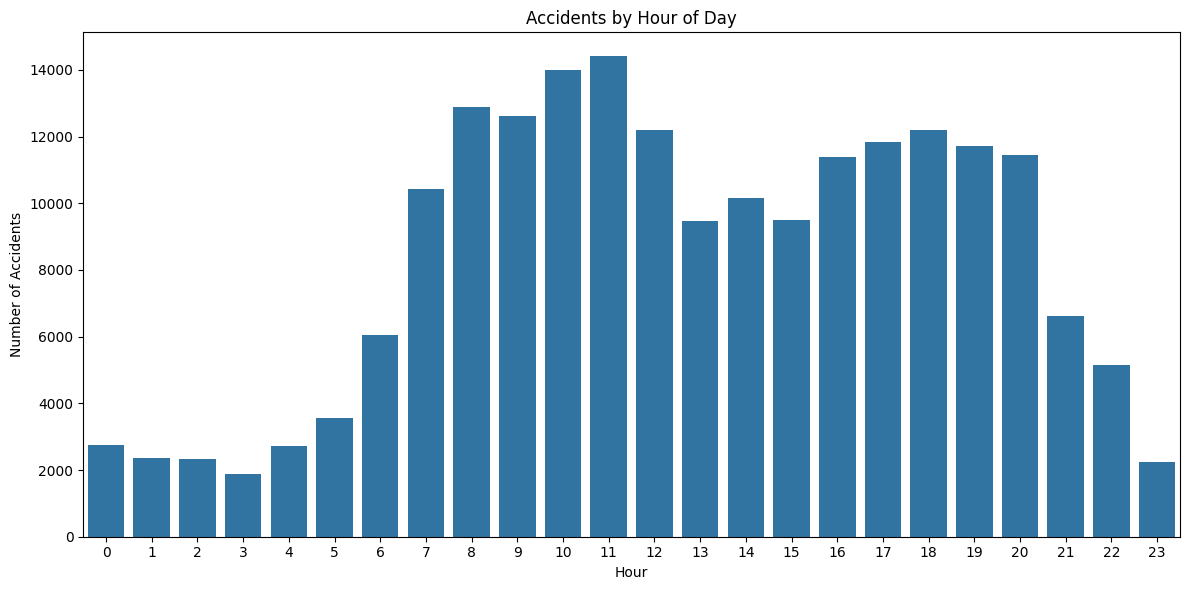

In [2]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

usecols = ['Start_Time','Start_Lat','Start_Lng','Weather_Condition','Severity']
df = pd.read_csv('US_Accidents_March23.csv', usecols=usecols, nrows=200_000)

df['Start_Time'] = df['Start_Time'].str.split('.').str[0]

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

df['Hour'] = df['Start_Time'].dt.hour

print(df[['Start_Time','Hour']].head())

plt.figure(figsize=(12,6))
sns.countplot(x='Hour', data=df)
plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Severity           200000 non-null  int64         
 1   Start_Time         200000 non-null  datetime64[ns]
 2   Start_Lat          200000 non-null  float64       
 3   Start_Lng          200000 non-null  float64       
 4   Weather_Condition  197212 non-null  object        
 5   Hour               200000 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(1)
memory usage: 8.4+ MB


,Severity,Start_Time,Start_Lat,Start_Lng,Weather_Condition,Hour
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Light Rain,5
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Light Rain,6
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Overcast,6
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Mostly Cloudy,7
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Mostly Cloudy,7


# Top 10 Weather Conditions During Accidents

- Counted top 10 weather conditions.
- Plotted a bar chart.
- Added title and labels.


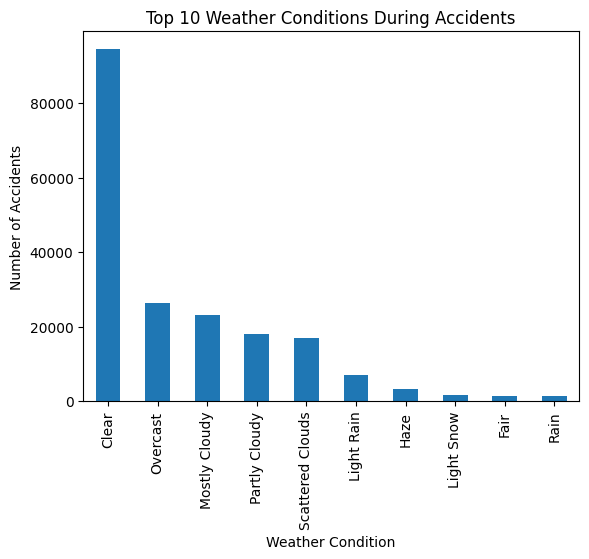

In [4]:

top_weather = df['Weather_Condition'].value_counts().head(10)

top_weather.plot(kind='bar')
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.show()


In [5]:
print(df.columns)


Index(['Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'Weather_Condition',
       'Hour'],
      dtype='object')


# Accidents by Weather Condition

- Counted weather conditions.
- Plotted a bar chart with rotated x-axis labels.


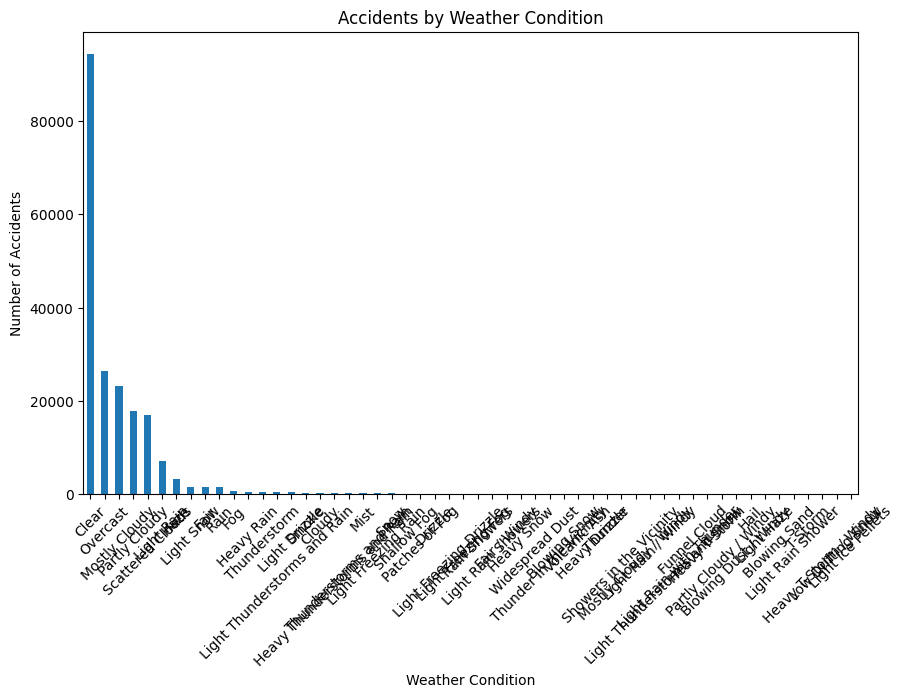

In [6]:

weather_counts = df['Weather_Condition'].value_counts()

weather_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Accidents by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()


# Heatmap of Accidents

- Sampled 10,000 rows from the data.
- Created a base map centered on the US.
- Added a heatmap layer using accident latitude and longitude.


In [7]:
import folium
from folium.plugins import HeatMap

sample_df = df.sample(n=10000)

m = folium.Map(location=[39.8283, -98.5795], zoom_start=5)

HeatMap(data=sample_df[['Start_Lat', 'Start_Lng']].dropna(), radius=8).add_to(m)

m


# Average Severity by Weather Condition

- Calculated average severity for top 10 weather conditions.
- Plotted a bar chart of average severity by weather.


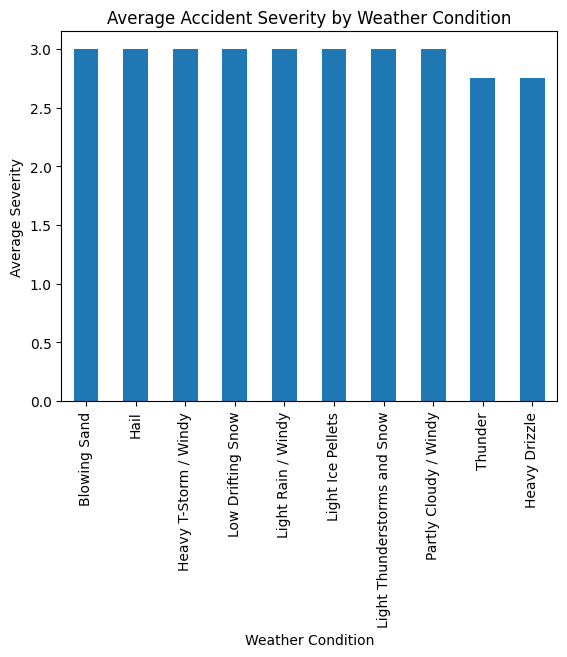

In [8]:

severity_weather = df.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False).head(10)

severity_weather.plot(kind='bar')
plt.title('Average Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Severity')
plt.show()


In [9]:
!pip install -U imbalanced-learn



[notice] A new release of pip available: 22.3 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import sys
print(sys.executable)
print(sys.version)


C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe
3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]


In [13]:
!"{sys.executable}" -m pip install imbalanced-learn


# Random Forest Model for Accident Severity Prediction

- Loaded dataset and created `Hour` column.
- One-hot encoded `Weather_Condition`.
- Split the data into features (`X`) and target (`y`).
- Applied SMOTE for class balancing.
- Trained a Random Forest classifier.
- Made predictions and evaluated model performance.


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

df = pd.read_csv('US_Accidents_March23.csv',
                 usecols=['Severity', 'Start_Time', 'Weather_Condition'],
                 parse_dates=['Start_Time'],
                 nrows=200_000)


df['Hour'] = df['Start_Time'].dt.hour

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
weather_ohe = ohe.fit_transform(df[['Weather_Condition']])
weather_cols = ohe.get_feature_names_out(['Weather_Condition'])
weather_df = pd.DataFrame(weather_ohe, columns=weather_cols, index=df.index)

X = pd.concat([df[['Hour']], weather_df], axis=1)
y = df['Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_res, y_res)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.32005
              precision    recall  f1-score   support

           1       0.00      0.29      0.00        24
           2       0.62      0.32      0.42     23570
           3       0.45      0.33      0.38     16375
           4       0.00      0.29      0.00        31

    accuracy                           0.32     40000
   macro avg       0.27      0.31      0.20     40000
weighted avg       0.55      0.32      0.40     40000

